# Cascading S-Parameters

Notebook for cascading S-parameters from individuals measurements of receiver componants in order to test the reconstructed $\Gamma_{\rm comp}$ vs. the directly measured $\Gamma_{\rm comp}$

$\Gamma_{\rm bulk} = S_{11} + \frac{S_{12}S_{21}\Gamma_L}{1-S_{\Gamma_{22}}\Gamma_L}$ (eq. 1.0)

where $\Gamma_L$ is the reflection coefficent at the output of a network with $S$-parameters descibed by $S_{ij}$

The componant described by the S-matrix
$S = \begin{pmatrix}
S_{11} & S_{12}\\
S_{21} & S_{22}
\end{pmatrix}$


May need measruements of the ABCD-matrix and T-parameters to form a full Scattering matrix to use in Eq. 1.0

May be required to convert from S-parqms to T- / ABCD- Params

$T_{\rm ABCD} = \begin{pmatrix}
A & B\\
C & D
\end{pmatrix}$
where

$A = \frac{(1+S_{11}) (1-S_{22}) +S_{12}S_{21}  }{2S_{21}} $

$B = Z_0 \frac{(1+S_{11})(1+S_{22}) - S_{12}S_{21}} {2S_{21}}$

$C = \frac{1}{Z_0} \frac{(1-S_{11})(1-S_{22})-S_{12}S_{21}}{2S_{21}} $

$D = \frac{(1-S_{11})(1+S_{22})+S_{12}S_{21}}{2S_{21}}$

The transmission forward can be cascaded through matrix multiplication with

$\boldsymbol{T}_{lump} = \boldsymbol{T}_{0}\boldsymbol{T}_{1} ...\boldsymbol{T}_{i}$

ensuring order is kept

where $Z_0$ is the characteristic line impedence, $50 \, \Omega$

To convert back

$S_{11} = \frac{A + B/Z_0 - CZ_0 - D}{A + B/Z_0 + CZ_0 + D}$

$S_{12} = \frac{2(AD - BC)}{A+B/Z_0 + CZ_0 + D}$

$S_{21} = \frac{2}{A + B/Z_0 +CZ_0 + D}$

$S_{22} = \frac{-A + B/Z_0 - CZ_0 + D}{A + B/Z_0 + CZ_0 + D}$



David M. Pozar, Microwave Engineering, 3rd ed., Wiley, 2005. 

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8534261

In [1]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

s2p_DIRECTORY = '/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock' # Change This to Point to your s2p file directory

In [2]:
def read_s2p(filename, flipped_measurement=False):
    """
    Reads a Touchstone .s2p file and returns:
        freq       → (N,) numpy array of frequencies (Hz)
        s_params   → (N, 2, 2) numpy array of complex S-parameters
    """

    # Storage
    freq = []
    s11 = []
    s21 = []
    s12 = []
    s22 = []

    data_format = None  # RI, MA, DB
    freq_multiplier = 1.0

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            # Skip comments
            if not line or line.startswith("!"):
                continue

            # Option line beginning with "#"
            if line.startswith("#"):
                parts = line.upper().split()
                # Detect frequency units
                if "HZ" in parts:
                    freq_multiplier = 1.0
                elif "KHZ" in parts:
                    freq_multiplier = 1e3
                elif "MHZ" in parts:
                    freq_multiplier = 1e6
                elif "GHZ" in parts:
                    freq_multiplier = 1e9

                # Detect S-parameter format
                if "RI" in parts:
                    data_format = "RI"
                elif "MA" in parts:
                    data_format = "MA"
                elif "DB" in parts:
                    data_format = "DB"
                continue

            # Parse numeric data lines
            values = line.split()
            if len(values) != 9:
                continue  # Not a valid S2P data row

            f_raw = float(values[0]) * freq_multiplier
            p = list(map(float, values[1:]))

            # p = [S11_a, S11_b, S21_a, S21_b, S12_a, S12_b, S22_a, S22_b]
            if data_format == "RI":
                c = lambda a, b: a + 1j * b
            elif data_format == "MA":
                c = lambda mag, ang_deg: mag * np.exp(1j * np.deg2rad(ang_deg))
            elif data_format == "DB":
                c = lambda db, ang_deg: 10**(db/20) * np.exp(1j * np.deg2rad(ang_deg))
            else:
                raise ValueError("S2P format not recognized (missing RI/MA/DB).")

            freq.append(f_raw)
            s11.append(c(p[0], p[1]))
            s21.append(c(p[2], p[3]))
            s12.append(c(p[4], p[5]))
            s22.append(c(p[6], p[7]))

    # Convert to array
    freq = np.array(freq)
    s_params = np.zeros((len(freq), 2, 2), dtype=complex)

    s11 = np.array(s11)
    s12 = np.array(s12)
    s21 = np.array(s21)
    s22 = np.array(s22)

    s_params[:, 0, 0] = s11
    s_params[:, 0, 1] = s12
    s_params[:, 1, 0] = s21
    s_params[:, 1, 1] = s22

    if flipped_measurement:
        return s22,s21,s12,s11, freq
    else:
        return s11,s12,s21,s22, freq

class Componant:
    def __init__(self,
                s2p_filepath=None,
                flipped_measurement = False,
                s11=None,
                s12=None,
                s21=None,
                s22=None,
                freqs=None,
                label=''):
        if s2p_filepath is None:
            if flipped_measurement:
                self.s11 = s22
                self.s12 = s21
                self.s21 = s12
                self.s22 = s11
            else:
                self.s11 = s11
                self.s12 = s12
                self.s21 = s21
                self.s22 = s22

            self.freqs = freqs
        else:
            self.s11, self.s12, self.s21, self.s22, self.freqs = read_s2p(s2p_filepath, flipped_measurement)
        self.label = label

    def transform_to_ABCD(self,
                        Z_0=50):
        self.A = ((1+self.s11)*(1-self.s22)+(self.s12*self.s21)) / (2*self.s21)
        self.B = Z_0 * ((1+self.s11)*(1+self.s22)-(self.s12*self.s21)) / (2*self.s21)
        self.C = ((1-self.s11)*(1-self.s22)-(self.s12*self.s21)) / (Z_0*2*self.s21)
        self.D = ((1-self.s11)*(1+self.s22)+(self.s12*self.s21)) / (2*self.s21)

        self.T_abcd = np.zeros((len(self.freqs), 2, 2), dtype=complex)

        self.T_abcd[:, 0, 0] = self.A
        self.T_abcd[:, 0, 1] = self.B
        self.T_abcd[:, 1, 0] = self.C
        self.T_abcd[:, 1, 1] = self.D


class LumpedComponants:
    def __init__(self,
                componants_list:list,
                Z_0=50,
                label = ''):
        self.componants_list = componants_list

        for c in componants_list:
            c.transform_to_ABCD()
            self.freqs = c.freqs
        self.T_abcd = self.componants_list[0].T_abcd

        for comp in self.componants_list[1:]:
            self.T_abcd = self.T_abcd @ comp.T_abcd

        self.convert_Tabcd_to_Sparams(Z_0=Z_0)
        self.label = label
        pass

    def convert_Tabcd_to_Sparams(self, Z_0=50):
        self.A = self.T_abcd[:, 0, 0]
        self.B = self.T_abcd[:, 0, 1]
        self.C = self.T_abcd[:, 1, 0]
        self.D = self.T_abcd[:, 1, 1]

        self.s11 = (self.A + (self.B / Z_0) - (self.C*Z_0) - self.D) / \
            (self.A + (self.B / Z_0) + (self.C*Z_0) + self.D)

        self.s12 = 2*((self.A*self.D) - (self.B*self.C)) / \
            (self.A + (self.B / Z_0) + (self.C*Z_0) + self.D)
        
        self.s21 = 2 / (self.A + (self.B / Z_0) + (self.C*Z_0) + self.D)

        self.s22 = (-self.A + (self.B / Z_0) - (self.C*Z_0) + self.D) / \
            (self.A + (self.B / Z_0) + (self.C*Z_0) + self.D)
        
        self.s_params = np.zeros((len(self.freqs), 2, 2), dtype=complex)
        self.s_params[:, 0, 0] = self.s11
        self.s_params[:, 0, 1] = self.s12
        self.s_params[:, 1, 0] = self.s21
        self.s_params[:, 1, 1] = self.s22


class Termination:
    def __init__(self,
                s2p_filepath=None,
                s11=None,
                freqs=None,
                flipped_measurement=False,
                label=None):
        if s2p_filepath is None:
            self.s11 = s11
            self.freqs = freqs
        else:
            self.s11, _, _, _, self.freqs = read_s2p(s2p_filepath, flipped_measurement)
        self.label = label

class LumpedTermination:
    def __init__(self,
                 lumped_componants,
                 termination,
                 label=None):
        self.lumped_componants = lumped_componants
        self.termination = termination

        self.freqs = lumped_componants.freqs
        self.s11 = calculate_bulk_reflection(lumped_componants,
                                             termination)
        self.label = label
        pass

def return_lumped_s11(componants,
                      termination):
    gamma_in = componants.s11 + ((componants.s12*componants.s21*termination.s11) / (1-(componants.s22*termination.s11)))
    return gamma_in

def calculate_bulk_reflection(componant,
                              termination):
    gamma_bulk = componant.s11 + ((componant.s12 * componant.s21 * termination.s11) / (1 - (componant.s22*termination.s11)))
    return gamma_bulk

Visulalise Componant S-Parameters

In [3]:
def plot_s_params_mag(componant,
                  figsize_inches=None,
                  frequency_unit='MHz',
                  xlim=(55, 85),
                  fontsize = 14,
                  savepath=None):
    
    unit_dict = {'MHz':1e6, 'GHz':1e9, 'kHz':1e3, 'Hz':1}
    d = unit_dict[frequency_unit]   
    fig, axes = plt.subplots(nrows=2,
                            ncols=2,
                            sharex=True,
                            layout='constrained')
    
    if isinstance(componant, list):
        for c in componant:
            axes[0,0].plot(c.freqs / d, 20*np.log10(c.s11), label=c.label)
            axes[0,1].plot(c.freqs / d, 20*np.log10(c.s12), label=c.label)
            axes[1,0].plot(c.freqs / d, 20*np.log10(c.s21), label=c.label)
            axes[1,1].plot(c.freqs / d, 20*np.log10(c.s22), label=c.label)
            axes[1,0].legend(fontsize=fontsize*0.9, frameon=False)
    else:
        axes[0,0].plot(componant.freqs / d, 20*np.log10(componant.s11))
        axes[0,1].plot(componant.freqs / d, 20*np.log10(componant.s12))
        axes[1,0].plot(componant.freqs / d, 20*np.log10(componant.s21))
        axes[1,1].plot(componant.freqs / d, 20*np.log10(componant.s22))

        fig.suptitle(componant.label, fontsize=fontsize*1.2)

    unit_dict = {'MHz':1e6, 'GHz':1e9, 'kHz':1e3, 'Hz':1}
    d = unit_dict[frequency_unit]
    axes[0,0].set_title(r'$S_{11}$', fontsize=fontsize)

    axes[0,1].set_title(r'$S_{12}$', fontsize=fontsize)

    axes[1,0].set_title(r'$S_{21}$', fontsize=fontsize)

    axes[1,1].set_title(r'$S_{22}$', fontsize=fontsize)

    for ax in axes.flat:
        ax.tick_params('both', labelsize=fontsize*0.9)
        ax.set_xlim(xmin = xlim[0],
                       xmax = xlim[-1])
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)

    fig.supxlabel(f'Frequency [{frequency_unit}]', fontsize=fontsize)
    fig.supylabel('[dB]')
    if figsize_inches is not None:
        plt.gcf().set_size_inches(figsize_inches)
    if savepath is not None:
        fig.savefig(savepath)
    plt.show()


def plot_s_params_phases(componant,
                  figsize_inches=None,
                  frequency_unit='MHz',
                  xlim=(55, 85),
                  fontsize = 14,
                  savepath=None):
    
    unit_dict = {'MHz':1e6, 'GHz':1e9, 'kHz':1e3, 'Hz':1}
    d = unit_dict[frequency_unit]   
    fig, axes = plt.subplots(nrows=2,
                            ncols=2,
                            sharex=True,
                            layout='constrained')
    if isinstance(componant, list):
        for c in componant:
            axes[0,0].plot(c.freqs / d, np.rad2deg(np.angle(c.s11)), label=c.label)
            axes[0,1].plot(c.freqs / d, np.rad2deg(np.angle(c.s12)), label=c.label)
            axes[1,0].plot(c.freqs / d, np.rad2deg(np.angle(c.s21)), label=c.label)
            axes[1,1].plot(c.freqs / d, np.rad2deg(np.angle(c.s22)), label=c.label)
            axes[1,0].legend(fontsize=fontsize*0.9, frameon=False)
    else:
        axes[0,0].plot(componant.freqs / d, np.rad2deg(np.angle(componant.s11)))
        axes[0,1].plot(componant.freqs / d, np.rad2deg(np.angle(componant.s12)))
        axes[1,0].plot(componant.freqs / d, np.rad2deg(np.angle(componant.s21)))
        axes[1,1].plot(componant.freqs / d, np.rad2deg(np.angle(componant.s22)))

        fig.suptitle(componant.label, fontsize=fontsize*1.2)

    axes[0,0].set_title(r'$S_{11}$', fontsize=fontsize)
    axes[0,0].tick_params('both', labelsize=fontsize*0.9)
    axes[0,0].set_xlim(xmin = xlim[0],
                       xmax = xlim[-1])

    axes[0,1].set_title(r'$S_{12}$', fontsize=fontsize)
    axes[0,1].tick_params('both', labelsize=fontsize*0.9)
    axes[0,1].set_xlim(xmin = xlim[0],
                       xmax = xlim[-1])

    axes[1,0].set_title(r'$S_{21}$', fontsize=fontsize)
    axes[1,0].tick_params('both', labelsize=fontsize*0.9)
    axes[1,0].set_xlim(xmin = xlim[0],
                       xmax = xlim[-1])

    axes[1,1].set_title(r'$S_{22}$', fontsize=fontsize)
    axes[1,1].tick_params('both', labelsize=fontsize*0.9)
    axes[1,1].set_xlim(xmin = xlim[0],
                       xmax = xlim[-1])

    for ax in axes.flat:
        ax.set_xlim(xmin=xlim[0], xmax=xlim[-1])
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)

    fig.supxlabel(f'Frequency [{frequency_unit}]', fontsize=fontsize)
    fig.supylabel('Phase Angle [deg.]')
    if figsize_inches is not None:
        plt.gcf().set_size_inches(figsize_inches)
    if savepath is not None:
        fig.savefig(savepath)
    plt.show()

def visualise_s11(termination,
                  figsize_inches=None,
                  frequency_unit='MHz',
                  xlim=(55, 85),
                  fontsize = 14,
                  savepath=None):
    unit_dict = {'MHz':1e6, 'GHz':1e9, 'kHz':1e3, 'Hz':1}
    d = unit_dict[frequency_unit]

    fig, (ax1, ax2) = plt.subplots(nrows=2,
                                   sharex=True,
                                   layout='constrained')
    if isinstance(termination, list):
        for c in termination:
            ax1.plot(c.freqs / d, 20*np.log10(c.s11), label=c.label)
            ax2.plot(c.freqs / d, np.rad2deg(np.angle(c.s11)), label=c.label)
            ax2.legend(fontsize=fontsize*0.9, frameon=False)
    else:
        ax1.plot(termination.freqs / d, 20*np.log10(termination.s11))
        ax2.plot(termination.freqs / d, np.rad2deg(np.angle(termination.s11)))
        
        fig.suptitle(termination.label, fontsize=fontsize*1.2)
    fig.supxlabel(f'Frequency [{frequency_unit}]', fontsize=fontsize)
    
    ax1.set_ylabel(r'$|S_{11}|$ [dB]', fontsize=fontsize)
    ax2.set_ylabel(r'$\angle S_{11}$ [deg.]', fontsize=fontsize)

    for ax in [ax1, ax2]:
        ax.set_xlim(xmin=xlim[0], xmax=xlim[-1])
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)
    if figsize_inches is not None:
        plt.gcf().set_size_inches(figsize_inches)
    if savepath is not None:
        fig.savefig(savepath)
    plt.show()

def visulaise_s11_residuals(prime_termination,
                            terminations,
                            figsize_inches=None,
                            frequency_unit='MHz',
                            xlim=(55, 85),
                            fontsize = 14,
                            diff_mag_ylim = None,
                            diff_pha_ylim = None,
                            savepath=None):
    unit_dict = {'MHz':1e6, 'GHz':1e9, 'kHz':1e3, 'Hz':1}
    d = unit_dict[frequency_unit]
    fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
    if isinstance(terminations, list):
        for t in terminations:
            del_s11_mag = 20*np.log10(prime_termination.s11) - 20*np.log10(t.s11)
            del_s11_phase = np.rad2deg(np.angle(prime_termination.s11) - np.angle(t.s11))
            ax1.plot(prime_termination.freqs / d, del_s11_mag, label=t.label)
            ax2.plot(prime_termination.freqs / d, del_s11_phase, label=t.label)
        ax2.legend(fontsize=fontsize*0.9, frameon=False)
    else:
        del_s11_mag = 20*np.log10(prime_termination.s11) - 20*np.log10(terminations.s11)
        del_s11_phase = np.rad2deg(np.angle(prime_termination.s11) - np.angle(terminations.s11))
        ax1.plot(prime_termination.freqs / d, del_s11_mag, label=t.label)
        ax2.plot(prime_termination.freqs / d, del_s11_phase, label=t.label)
    ax1.set_ylabel(r'$\Delta |S_{11}|$ [dB]', fontsize=fontsize)
    ax2.set_ylabel(r'$\Delta \angle S_{11}$ [deg.]', fontsize=fontsize)

    for ax in [ax1, ax2]:
        ax.set_xlim(xmin=xlim[0], xmax=xlim[-1])
        ax.relim()
        ax.autoscale_view(scalex=False, scaley=True)

    if diff_mag_ylim is not None:
        ax1.set_ylim(ymin = min(diff_mag_ylim),
                     ymax = max(diff_mag_ylim))
    
    if diff_pha_ylim is not None:
        ax2.set_ylim(ymin = min(diff_pha_ylim),
                     ymax = max(diff_pha_ylim))

    fig.supxlabel(f'Frequency [{frequency_unit}]', fontsize=fontsize)
    if figsize_inches is not None:
        plt.gcf().set_size_inches(figsize_inches)
    if savepath is not None:
        fig.savefig(savepath)
    plt.show()



/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


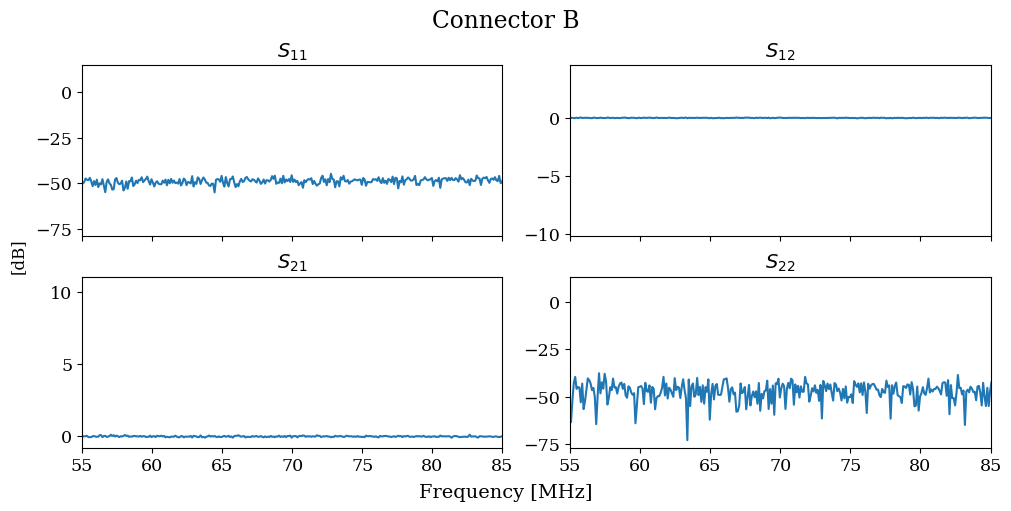

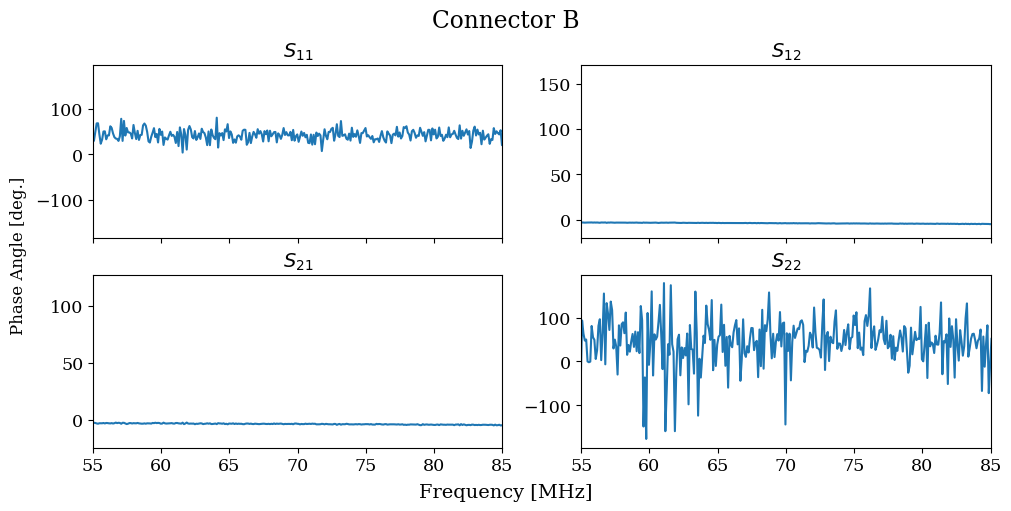

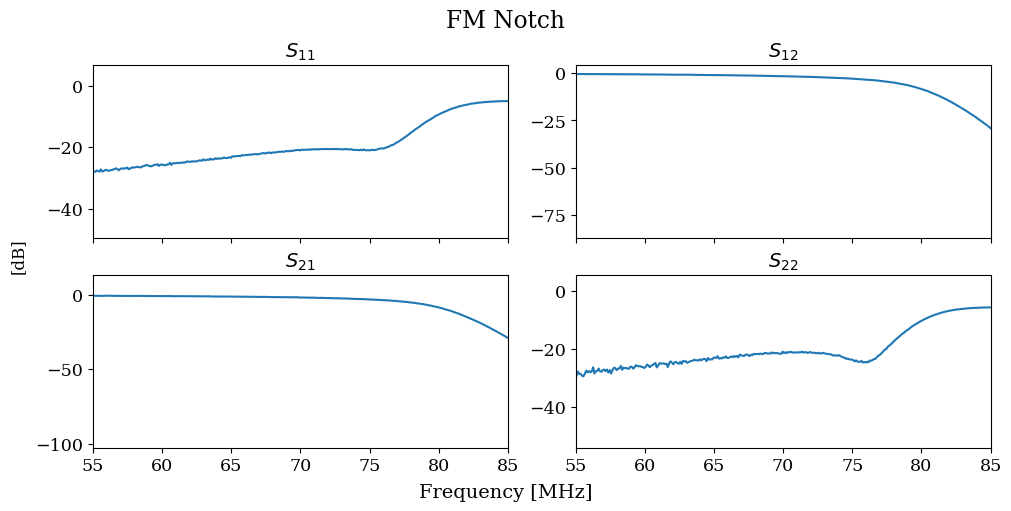

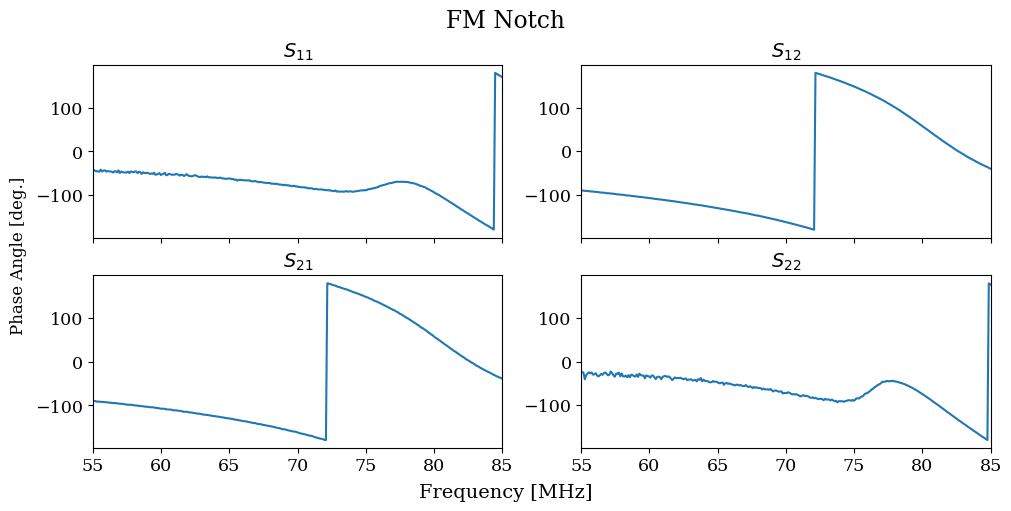

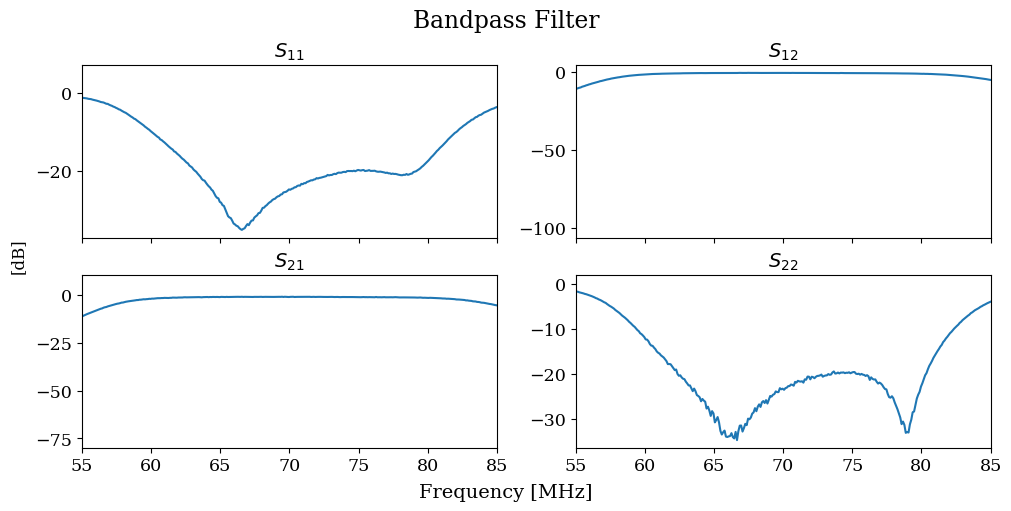

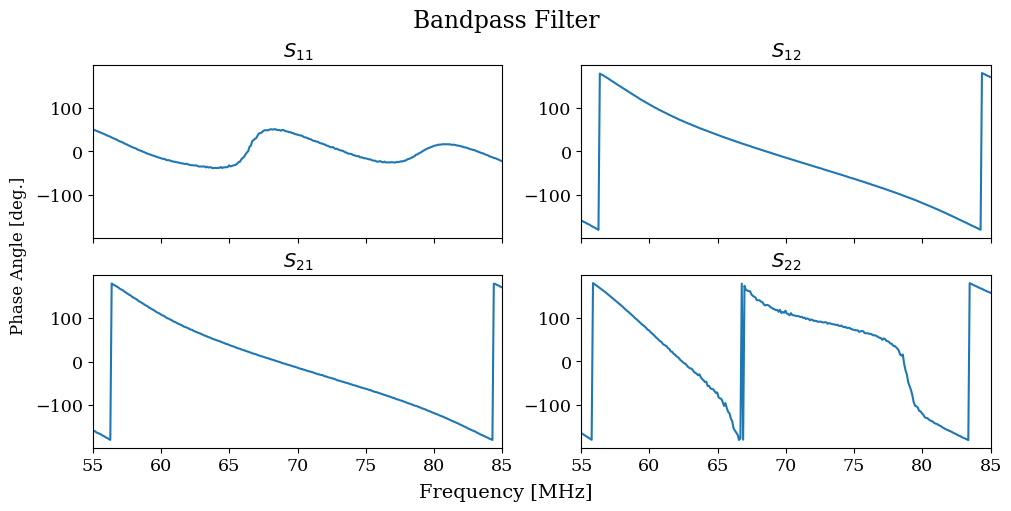

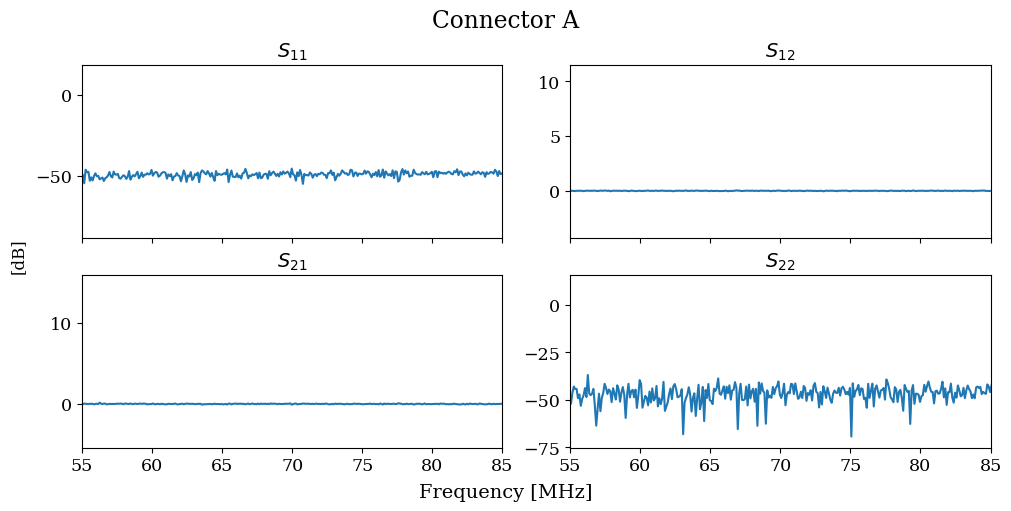

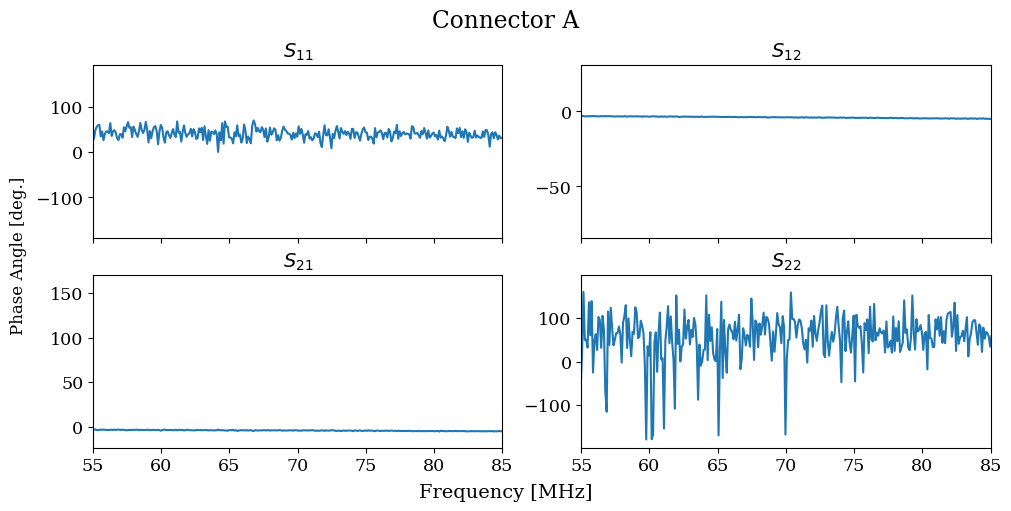

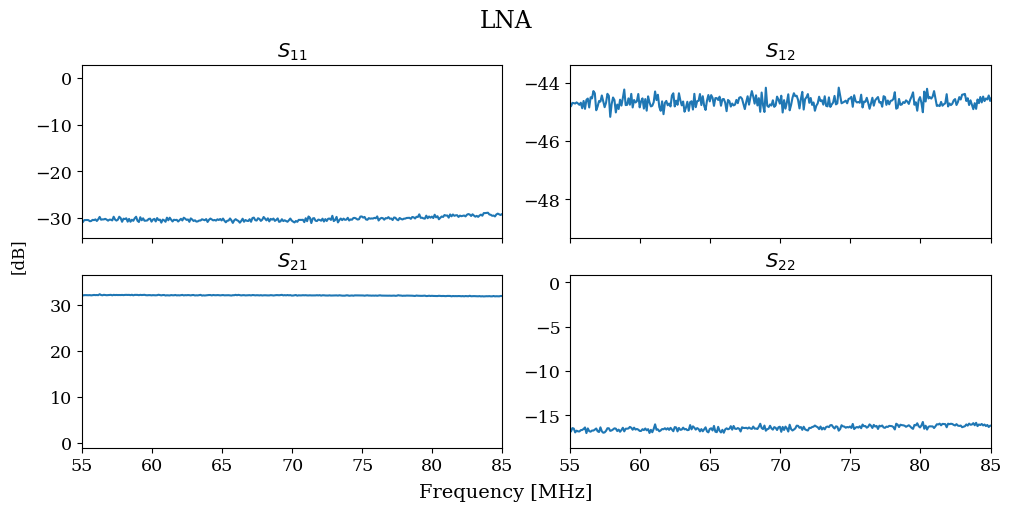

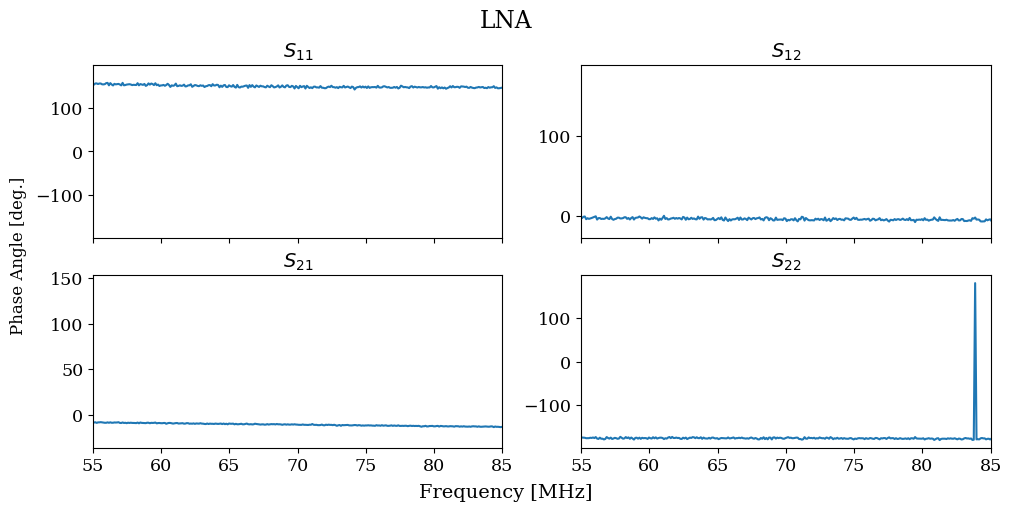

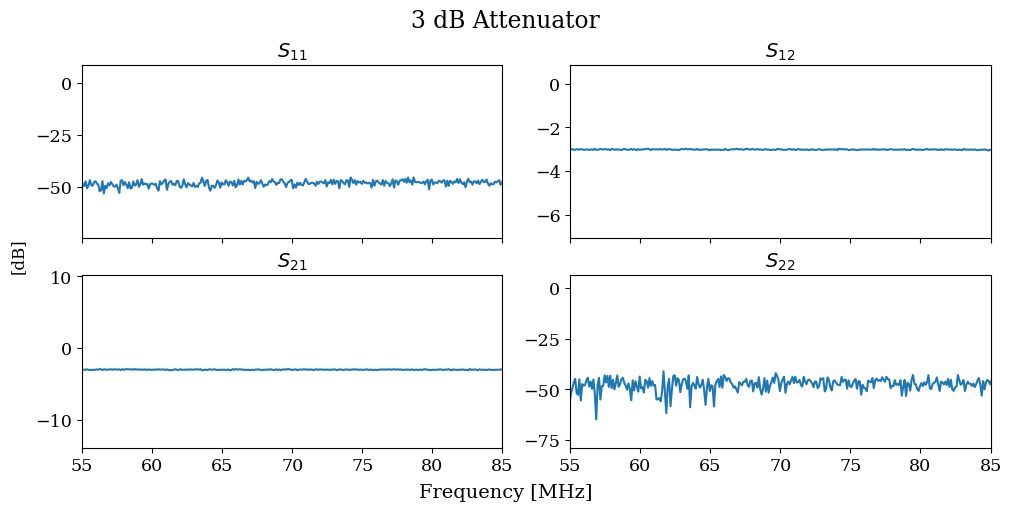

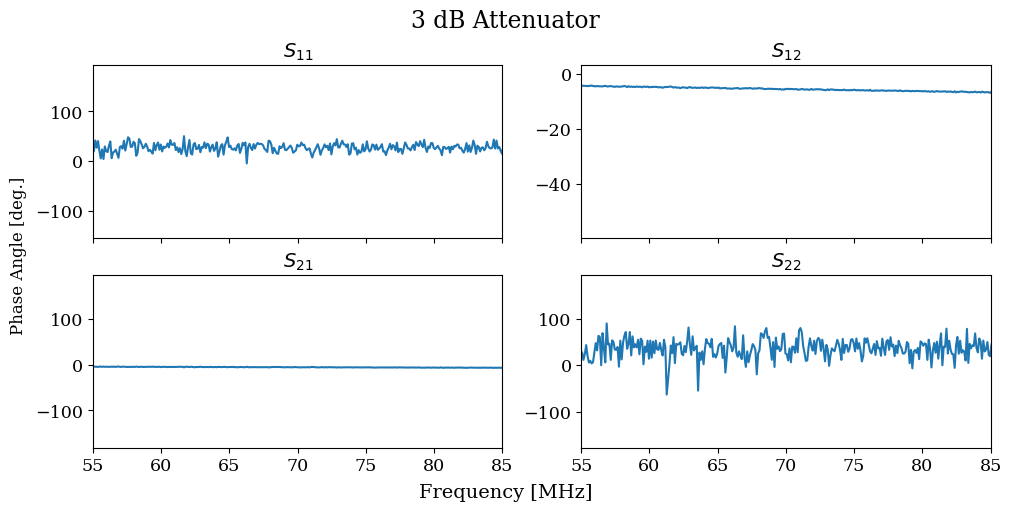

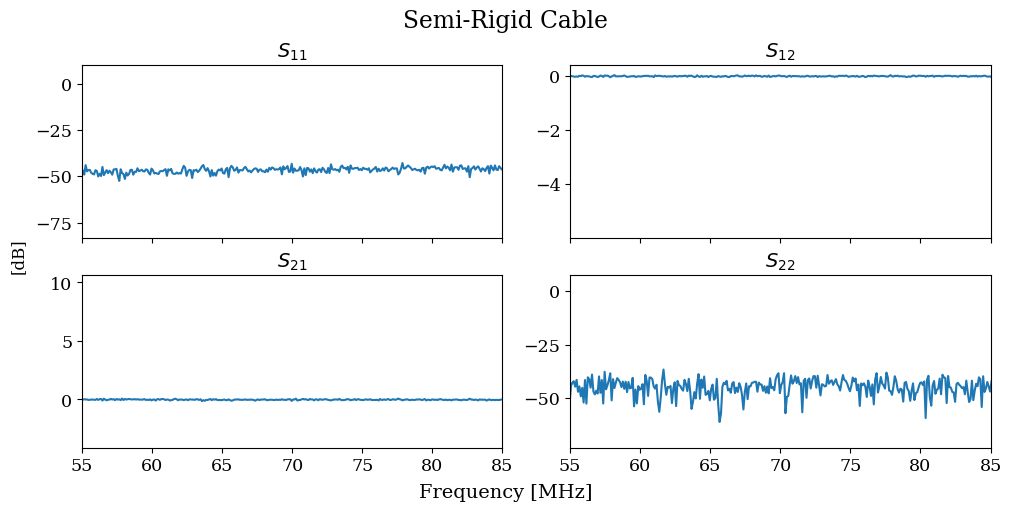

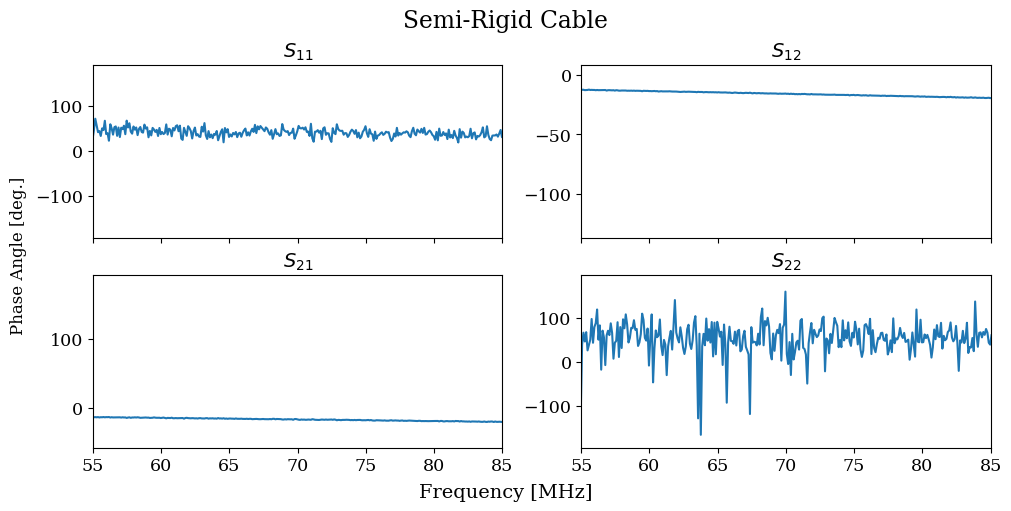

In [4]:
receiver_block = Componant(f'{s2p_DIRECTORY}/RecBlock0.s2p', label='Receiver Block')

# individual_comps

connB = Componant(f'{s2p_DIRECTORY}/adapterB1.s2p', label='Connector B')
FMNotch = Componant(f'{s2p_DIRECTORY}/FMNotch3.s2p', label='FM Notch')
BPFilter = Componant(f'{s2p_DIRECTORY}/BandpassFil3.s2p', label='Bandpass Filter')
connA = Componant(f'{s2p_DIRECTORY}/adapterA1.s2p', label='Connector A')
LNA = Componant(f'{s2p_DIRECTORY}/LNA3.s2p', label='LNA')
att3dB = Componant(f'{s2p_DIRECTORY}/3dBatt3.s2p', label='3 dB Attenuator')
semirigid = Componant(f'{s2p_DIRECTORY}/SemiRigid1.s2p', label='Semi-Rigid Cable')

plot_s_params_mag(connB)
plot_s_params_phases(connB)
plot_s_params_mag(FMNotch)
plot_s_params_phases(FMNotch)
plot_s_params_mag(BPFilter)
plot_s_params_phases(BPFilter)
plot_s_params_mag(connA)
plot_s_params_phases(connA)
plot_s_params_mag(LNA)
plot_s_params_phases(LNA)
plot_s_params_mag(att3dB)
plot_s_params_phases(att3dB)
plot_s_params_mag(semirigid)
plot_s_params_phases(semirigid)



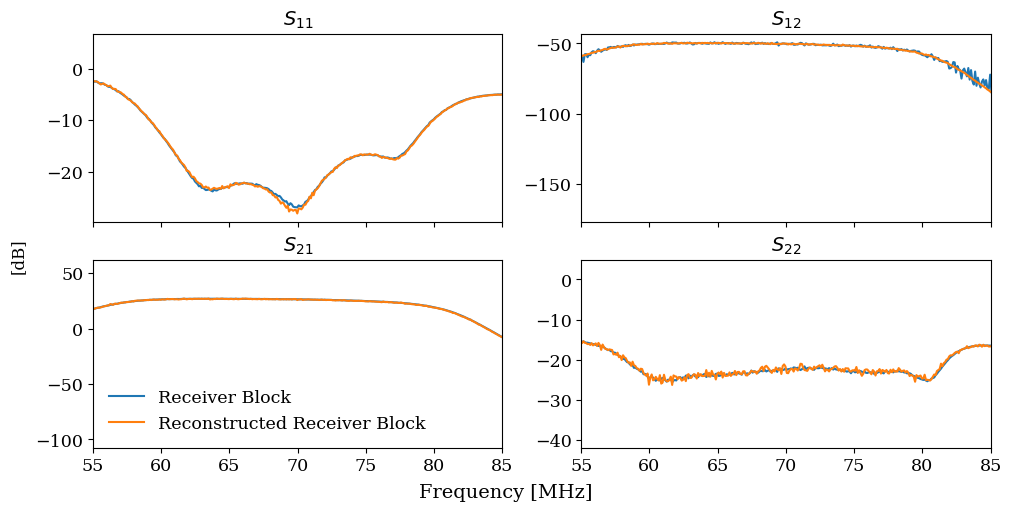

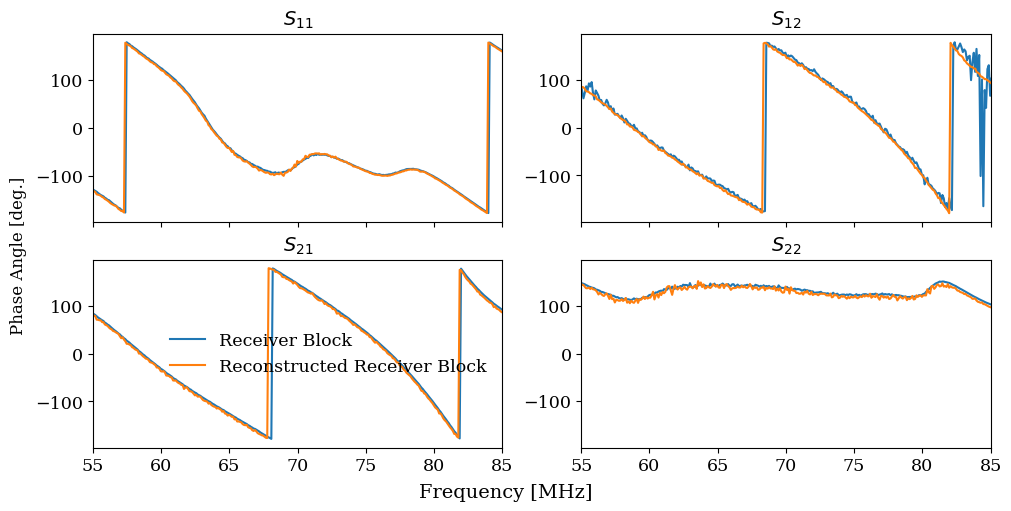

In [5]:

lump = [connB, FMNotch, BPFilter, connA, LNA, att3dB, semirigid]

lumped_receiver_block = LumpedComponants(lump, label = 'Reconstructed Receiver Block')



plot_s_params_mag([receiver_block, lumped_receiver_block])
plot_s_params_phases([receiver_block, lumped_receiver_block])



### Lumped Terminated S11

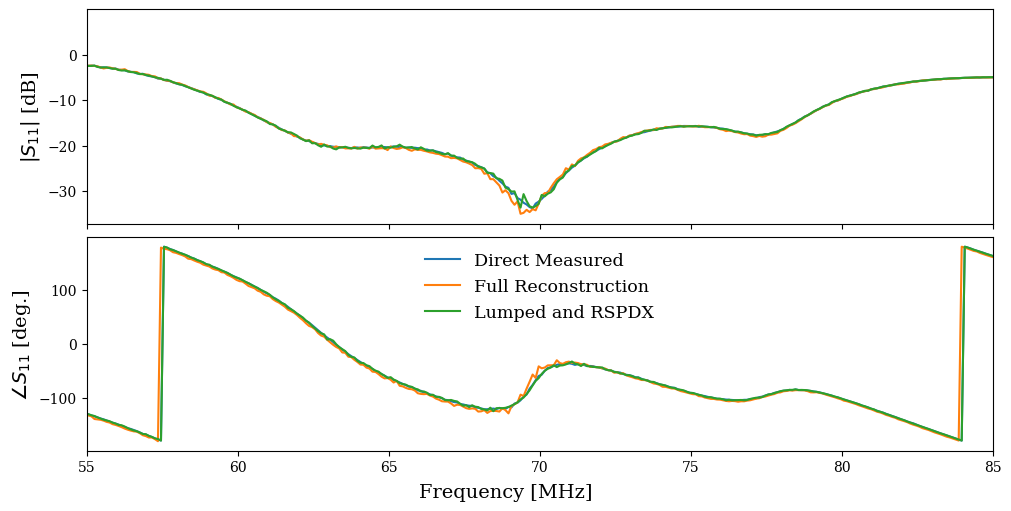

In [6]:
direct_measured = Termination(s2p_filepath=f'{s2p_DIRECTORY}/RecBlockSDR3.s2p', label='Direct Measured')

rspdx = Termination(s2p_filepath=f'{s2p_DIRECTORY}/RSPdx1.s2p')
indivudal_reconstruction = LumpedTermination(lumped_componants=lumped_receiver_block,
                                             termination=rspdx, label='Full Reconstruction')

bulk_and_rpsdx = LumpedTermination(lumped_componants=receiver_block,
                                   termination=rspdx,
                                   label='Lumped and RSPDX')

visualise_s11(termination=[direct_measured, indivudal_reconstruction, bulk_and_rpsdx])

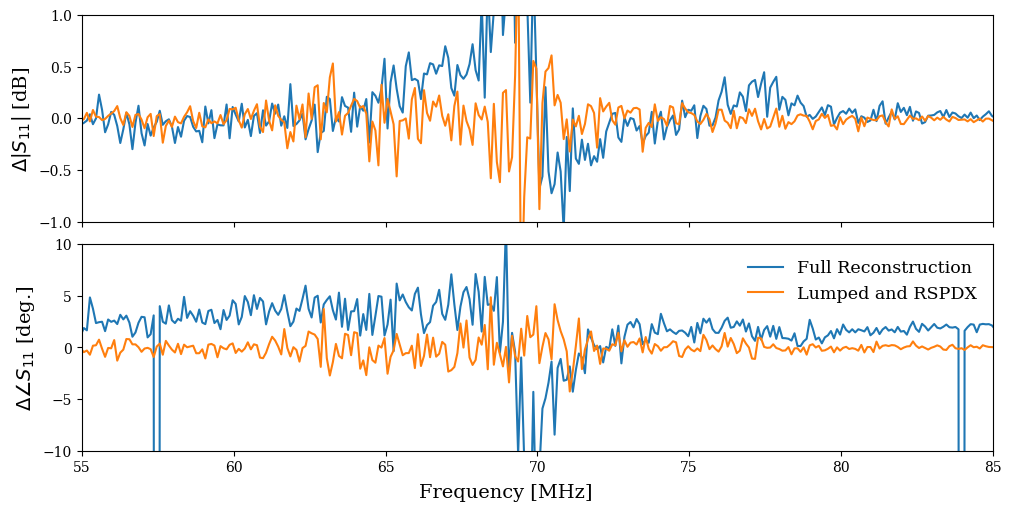

In [7]:
visulaise_s11_residuals(prime_termination=direct_measured,
                        terminations=[indivudal_reconstruction, bulk_and_rpsdx],
                        diff_mag_ylim=(-1, 1),
                        diff_pha_ylim=(-10, 10))

### Calibration Sources

In [8]:
cal_open = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_open_t1t1e8_0.s2p',
                       label='Open Cal')

cal_short = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_short_t1t1e7_0.s2p',
                       label='Short Cal')

sp8t_to_open = Componant(s2p_filepath='VNA_Measurements_John/sp8t/sp8t_p8_rf8.s2p', label='SP8T')
sp8t_to_short = Componant(s2p_filepath='VNA_Measurements_John/sp8t/sp8t_p8_rf8.s2p', label='SP8T')

open_term = Termination(s2p_filepath='VNA_Measurements_John/cal_ends/open_0.s2p')
short_term = Termination(s2p_filepath='VNA_Measurements_John/cal_ends/short_0.s2p')

recon_open = LumpedTermination(lumped_componants=sp8t_to_open,
                               termination=open_term, label='Recon. Open')
recon_short = LumpedTermination(lumped_componants=sp8t_to_short,
                               termination=short_term, label='Recon. Short')



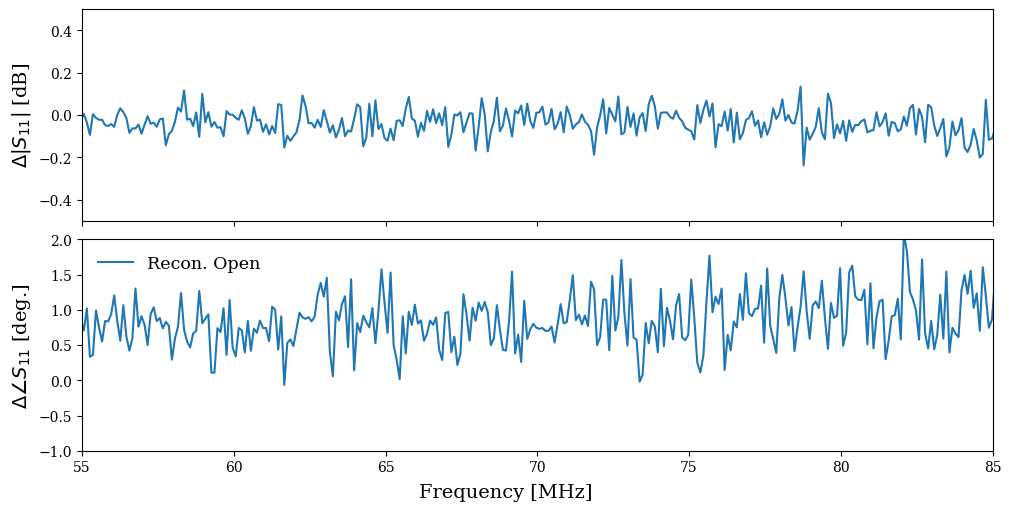

In [9]:
visulaise_s11_residuals(prime_termination=cal_open,
                        terminations=[recon_open],
                        diff_mag_ylim=(-0.5,0.5),
                        diff_pha_ylim=(-1,2))

### Reconstruct Long Cable Sources

/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


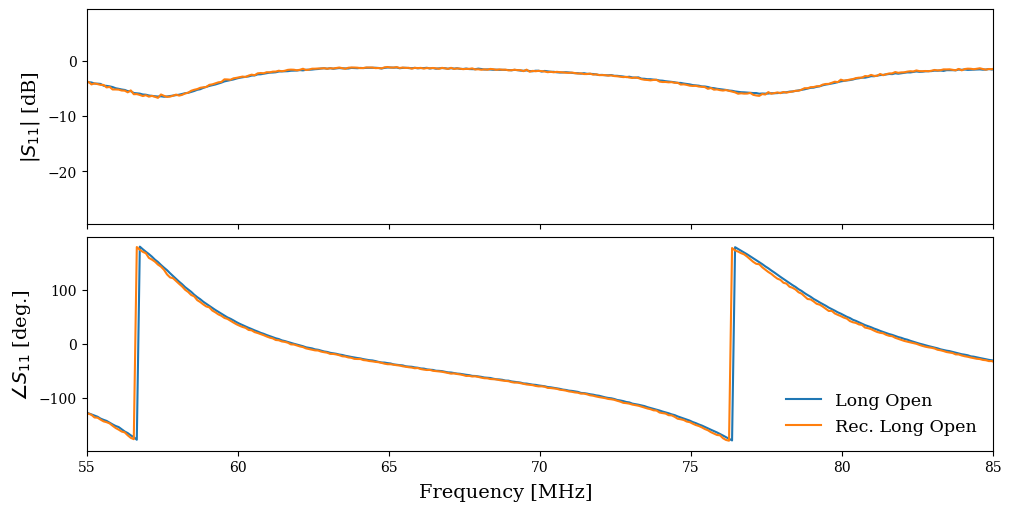

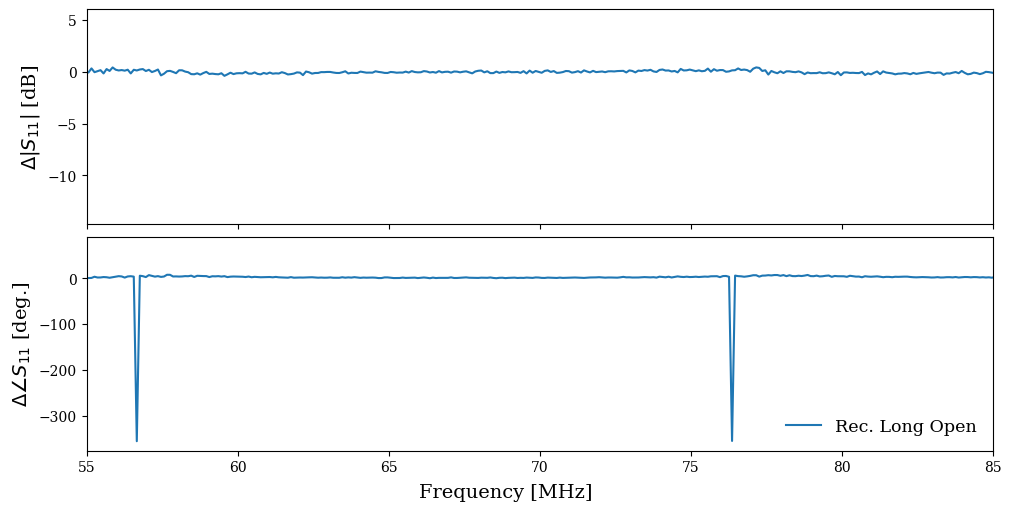

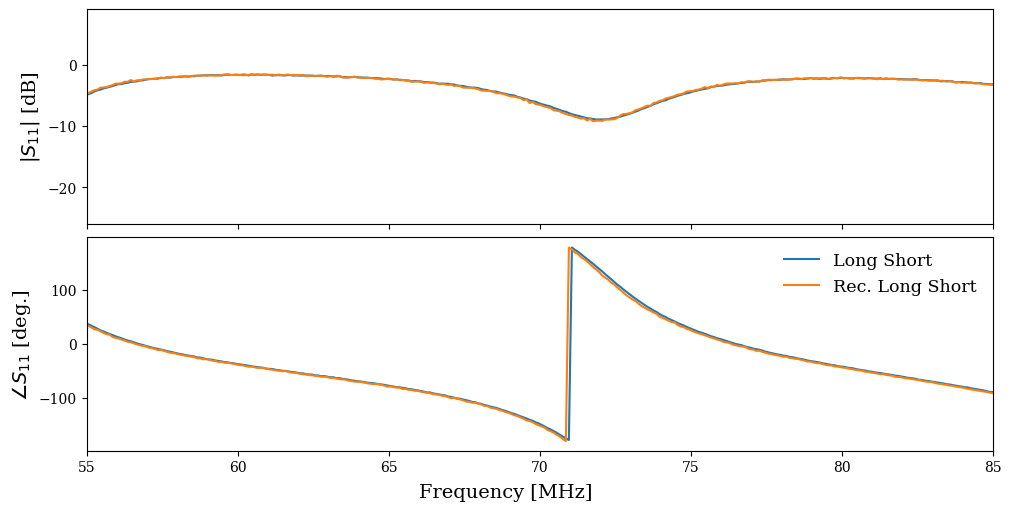

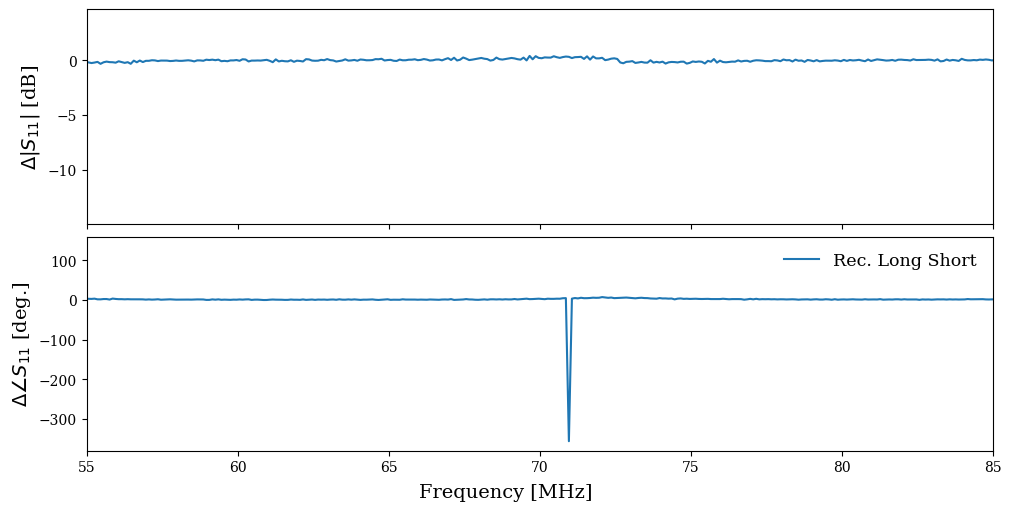

In [15]:
cal_long_open = Termination('VNA_Measurements_John/cal_s11/cal_longopen_t1t1e3_2.s2p', label='Long Open')
cal_long_short = Termination('VNA_Measurements_John/cal_s11/cal_longshort_t2t1e3_2.s2p', label='Long Short')

spdt_open_term = Termination(s2p_filepath='VNA_Measurements_John/spdt1_openshort/spdtopenrf1_0.s2p')
spdt_short_term = Termination(s2p_filepath='VNA_Measurements_John/spdt1_openshort/spdtshortrf2_0.s2p')

long_cable = Componant(s2p_filepath='VNA_Measurements_John/longcable/longcable_0.s2p', label='Long Cable')

sp8t_to_long_cable = Componant(s2p_filepath='VNA_Measurements_John/sp8t/sp8t_p3_rf3.s2p', label='SP8T Port 3 Through')

sp8t_long_cable = LumpedComponants(componants_list=[sp8t_to_long_cable, long_cable])

lumped_long_open = LumpedTermination(lumped_componants=sp8t_long_cable,
                                     termination=spdt_open_term,
                                     label='Rec. Long Open')
lumped_long_short = LumpedTermination(lumped_componants=sp8t_long_cable,
                                      termination=spdt_short_term,
                                      label='Rec. Long Short')

visualise_s11(termination=[cal_long_open, lumped_long_open])
visulaise_s11_residuals(prime_termination=cal_long_open, terminations=[lumped_long_open])
visualise_s11(termination=[cal_long_short, lumped_long_short])

visulaise_s11_residuals(prime_termination=cal_long_short, terminations=[lumped_long_short])

### Calibration Sources

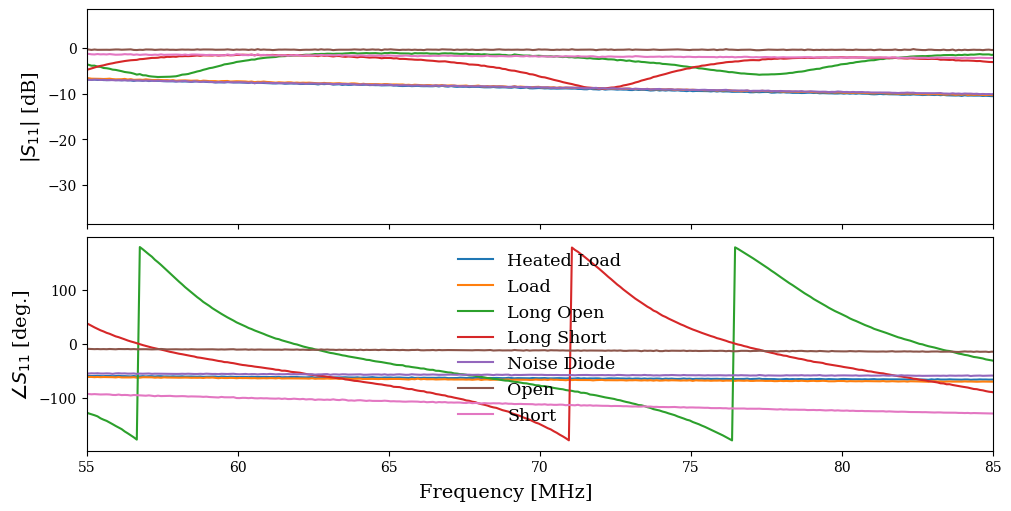

In [11]:
heated_load = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_heatedload_t1t1e4_0.s2p',
                          label='Heated Load')

load = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_load_t1t1e1_0.s2p',
                   label='Load')

long_open = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_longopen_t1t1e3_0.s2p',
                        label='Long Open')

long_short = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_longshort_t2t1e3_0.s2p',
                         label='Long Short')

noise_diode = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_noisediode_t1t1e2_0.s2p',
                          label='Noise Diode')

open_t = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_open_t1t1e8_0.s2p',
                     label='Open')
short_t = Termination(s2p_filepath='VNA_Measurements_John/cal_s11/cal_short_t1t1e7_0.s2p',
                      label='Short')

visualise_s11(termination=[heated_load,
                           load,
                           long_open,
                           long_short,
                           noise_diode,
                           open_t,
                           short_t])

## Recovering Total $S_{11}$ from Individual Component Measurements

### Load

/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


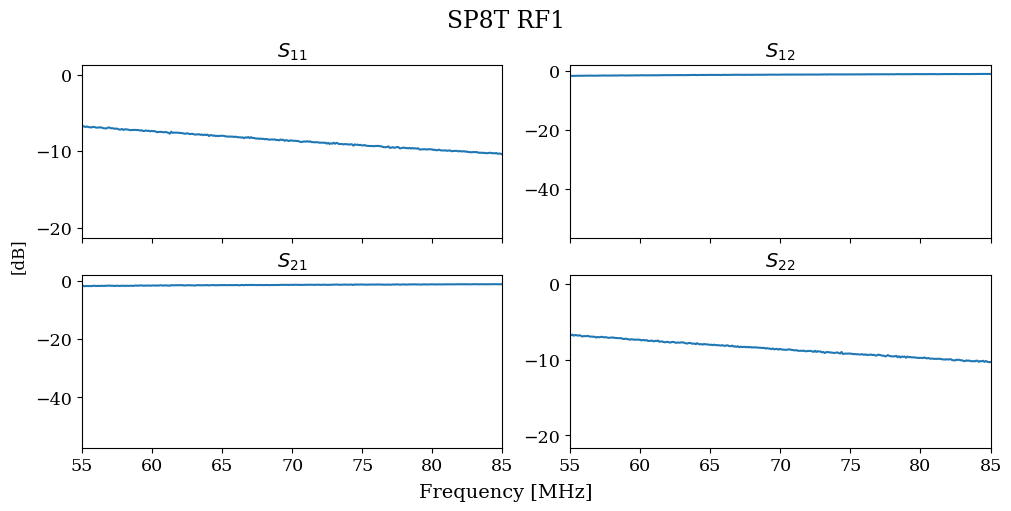

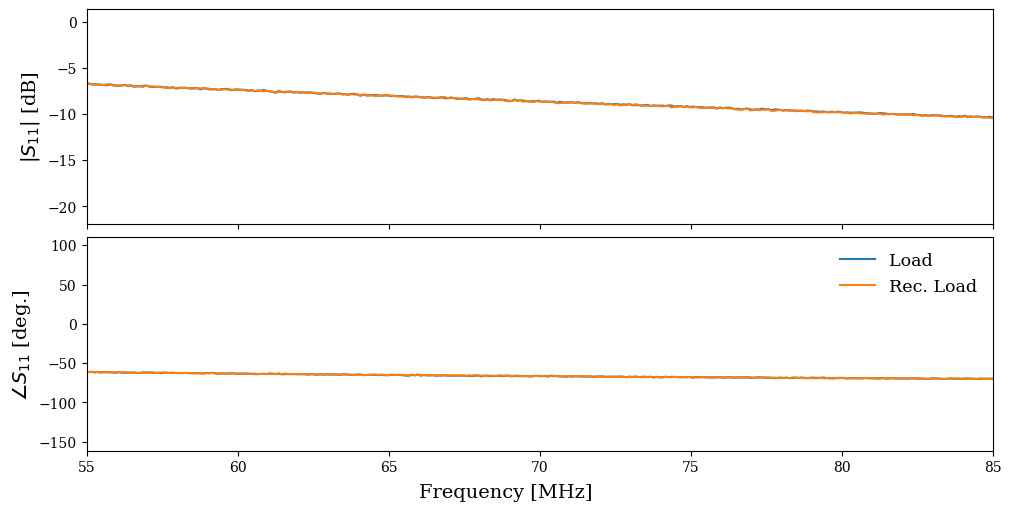

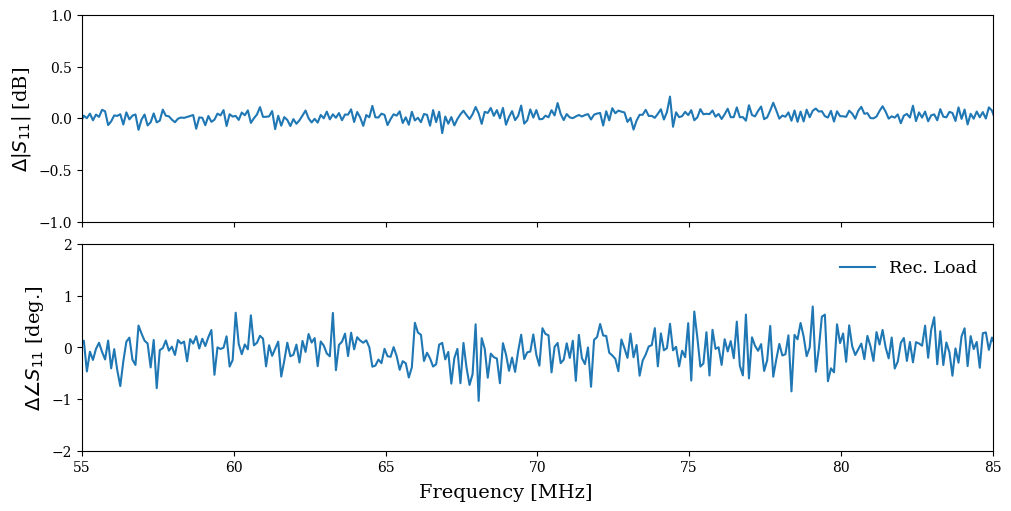

In [18]:
## Load in the Load

cal_load = Termination('VNA_Measurements_John/cal_s11/cal_load_t1t1e1_0.s2p', label='Load')

sp8t_rf1 = Componant('VNA_Measurements_John/sp8t/sp8t_p1_rf1.s2p', label='SP8T RF1')

load_term = Termination('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/cal_ends/load_0.s2p')

rec_load = LumpedTermination(lumped_componants=sp8t_rf1, termination=load_term, label='Rec. Load')

plot_s_params_mag(sp8t_rf1)

visualise_s11(termination=[cal_load, rec_load])
visulaise_s11_residuals(prime_termination=cal_load,
terminations=[rec_load], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-2, 2))

### Noise Diode

/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


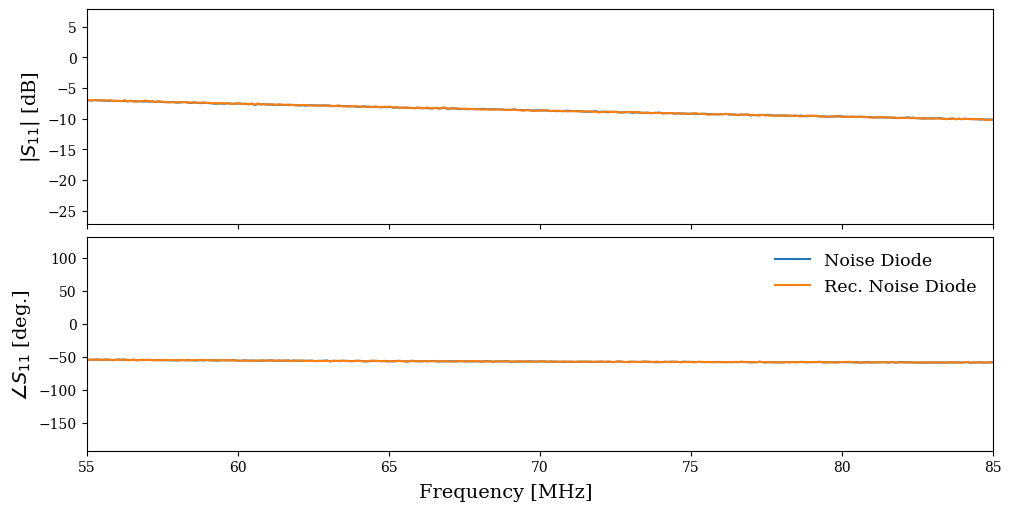

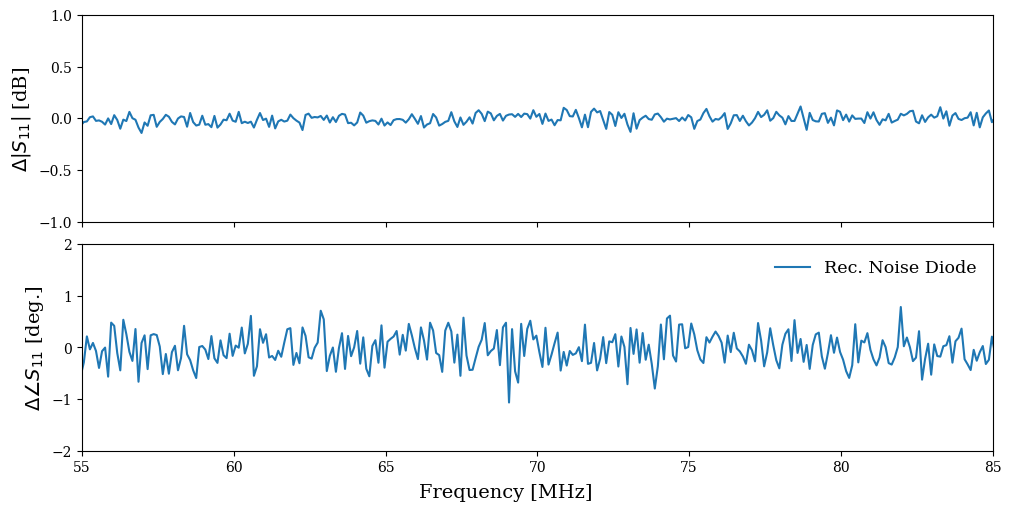

In [ ]:
cal_noisediode = Termination('VNA_Measurements_John/cal_s11/cal_noisediode_t1t1e2_0.s2p', label='Noise Diode')

sp8t_rf2 = Componant('VNA_Measurements_John/sp8t/sp8t_p2_rf2.s2p', label='SP8T RF2')

noisediode_term = Termination('VNA_Measurements_John/cal_ends/noisediode_0.s2p')

rec_noisediode = LumpedTermination(lumped_componants=sp8t_rf2, termination=noisediode_term, label='Rec. Noise Diode')

visualise_s11(termination=[cal_noisediode, rec_noisediode])
visulaise_s11_residuals(prime_termination=cal_noisediode,
terminations=[rec_noisediode], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-2, 2))

### Long Open Calibrator

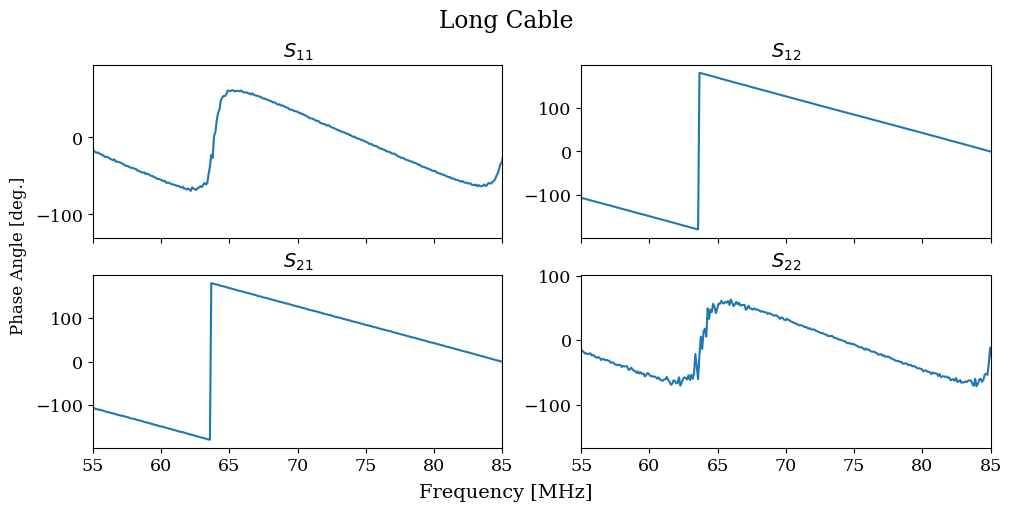

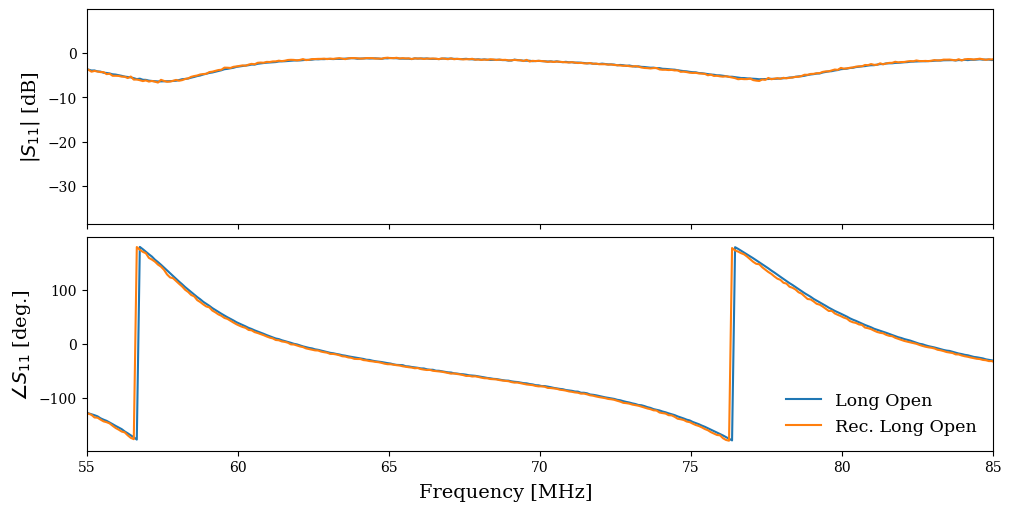

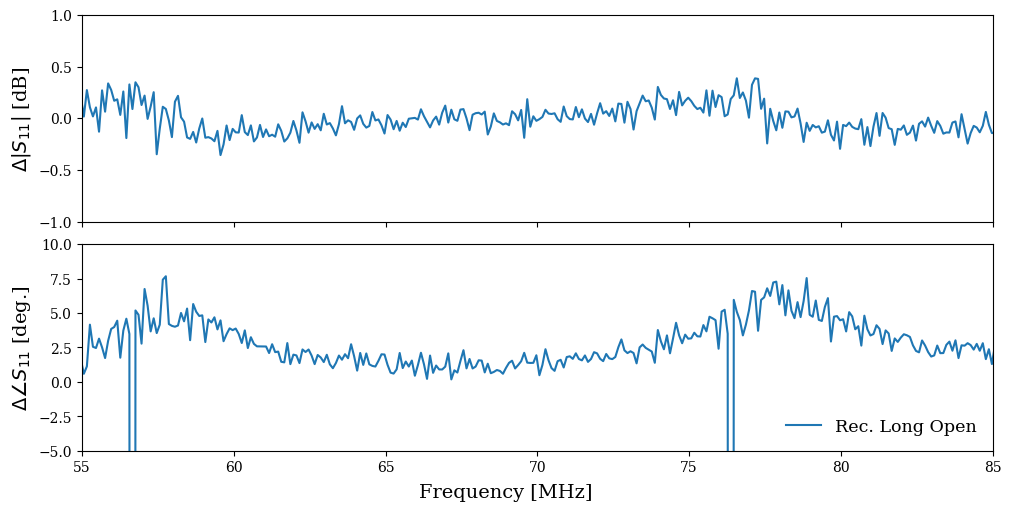

In [29]:
cal_longopen = Termination('VNA_Measurements_John/cal_s11/cal_longopen_t1t1e3_0.s2p', label='Long Open')

sp8t_rf3 = Componant('VNA_Measurements_John/sp8t/sp8t_p3_rf3.s2p', label='SP8T RF3')

longcable = Componant('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/longcable/longcable_0.s2p', label='Long Cable')

plot_s_params_phases(longcable)

spdt_open = Termination('VNA_Measurements_John/spdt1_openshort/spdtopenrf1_0.s2p')

rec_longopen = LumpedTermination(lumped_componants=LumpedComponants([sp8t_rf3, longcable]), termination=spdt_open, label='Rec. Long Open')

visualise_s11(termination=[cal_longopen, rec_longopen])
visulaise_s11_residuals(prime_termination=cal_longopen,
terminations=[rec_longopen], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

### Long Short



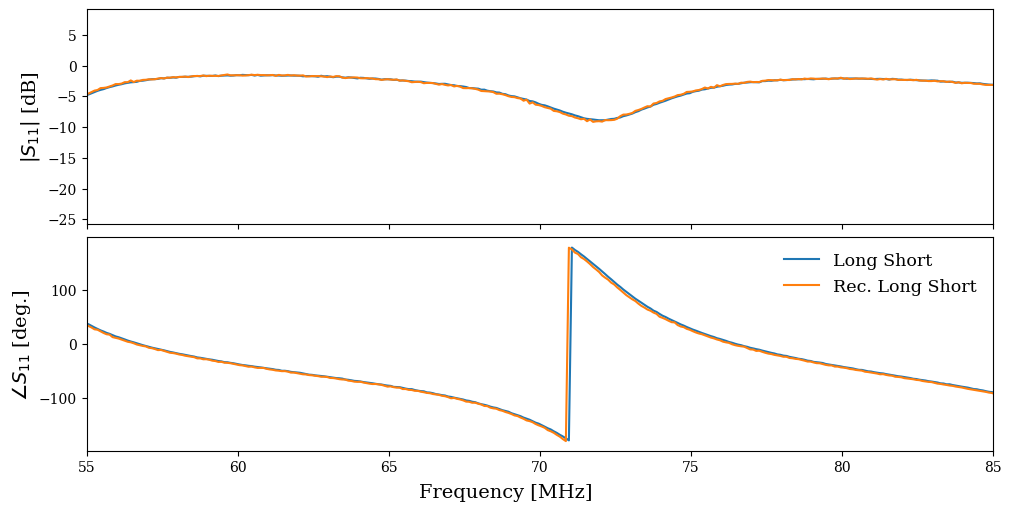

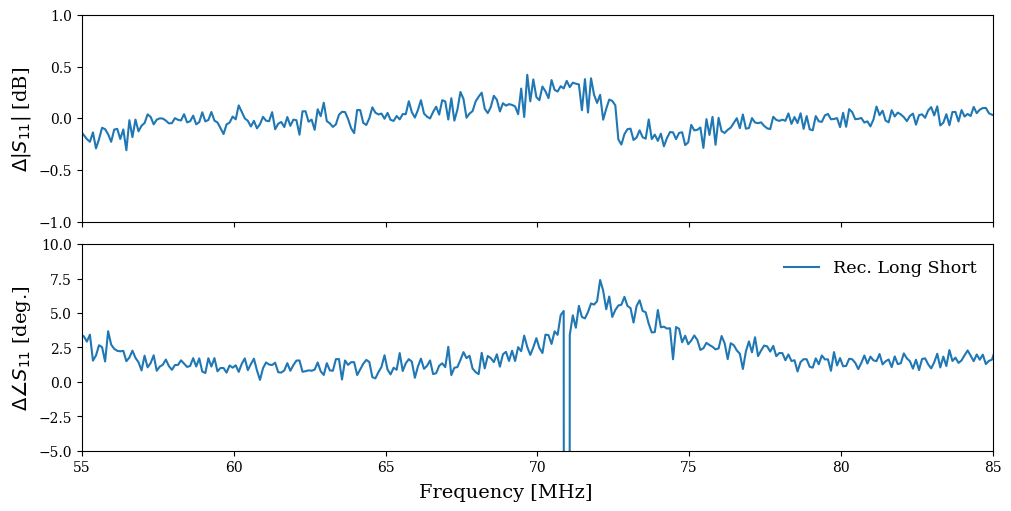

In [28]:
cal_longshort = Termination('VNA_Measurements_John/cal_s11/cal_longshort_t2t1e3_0.s2p', label='Long Short')

sp8t_rf3 = Componant('VNA_Measurements_John/sp8t/sp8t_p3_rf3.s2p', label='SP8T RF3')

longcable = Componant('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/longcable/longcable_0.s2p', label='Long Cable')

spdt_short = Termination('VNA_Measurements_John/spdt1_openshort/spdtshortrf2_0.s2p')

rec_longshort = LumpedTermination(lumped_componants=LumpedComponants([sp8t_rf3, longcable]), termination=spdt_short, label='Rec. Long Short')

visualise_s11(termination=[cal_longshort, rec_longshort])
visulaise_s11_residuals(prime_termination=cal_longshort,
terminations=[rec_longshort], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

### Heated Load


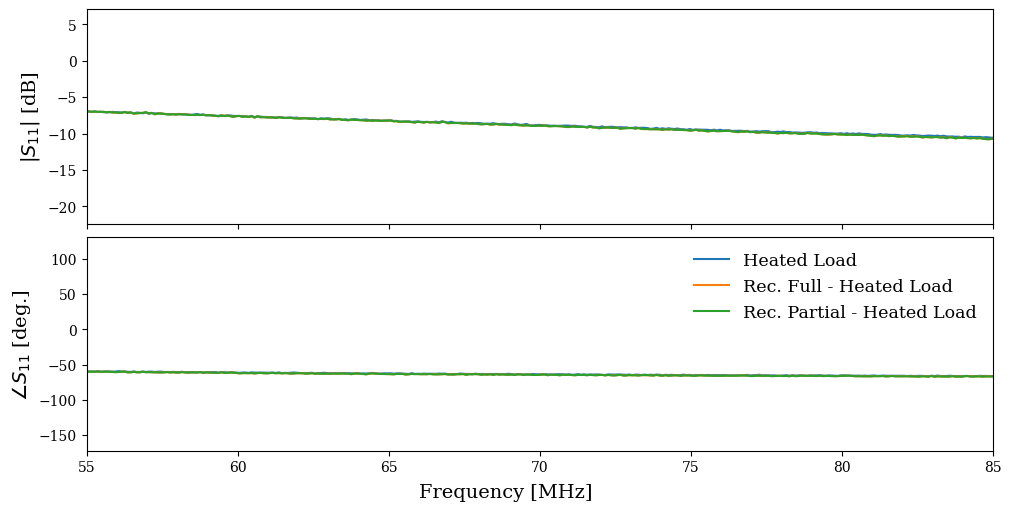

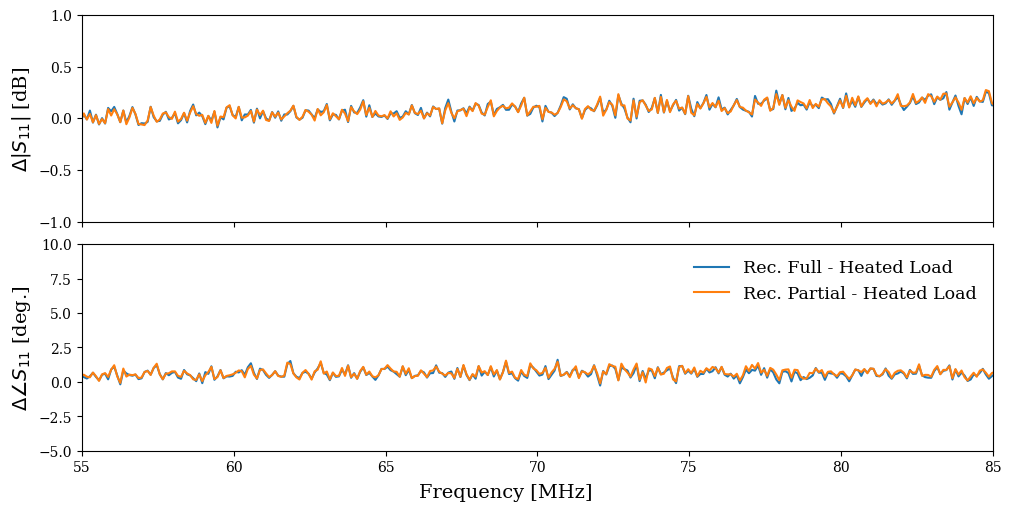

In [26]:
cal_heatedload = Termination('VNA_Measurements_John/cal_s11/cal_heatedload_t1t1e4_0.s2p', label='Heated Load')

sp8t_rf4 = Componant('VNA_Measurements_John/sp8t/sp8t_p2_rf2.s2p', label='SP8T RF4')

semi_rigidcable = Componant('VNA_Measurements_John/heated_load/semi_rigid_0.s2p', label='Long Cable')

heated_load_term = Termination('VNA_Measurements_John/heated_load/load_terminstion_1.s2p')

full_heated_load_term = Termination('VNA_Measurements_John/heated_load/full_heated_load_0.s2p')

rec_heated_load_0 = LumpedTermination(lumped_componants=LumpedComponants([sp8t_rf4, semi_rigidcable]), termination=heated_load_term, label='Rec. Full - Heated Load')
rec_heated_load_1 = LumpedTermination(lumped_componants=sp8t_rf4, termination=full_heated_load_term, label='Rec. Partial - Heated Load')

visualise_s11(termination=[cal_heatedload, rec_heated_load_0, rec_heated_load_1])
visulaise_s11_residuals(prime_termination=cal_heatedload,
terminations=[rec_heated_load_0, rec_heated_load_1], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

### Short Calibrator


/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


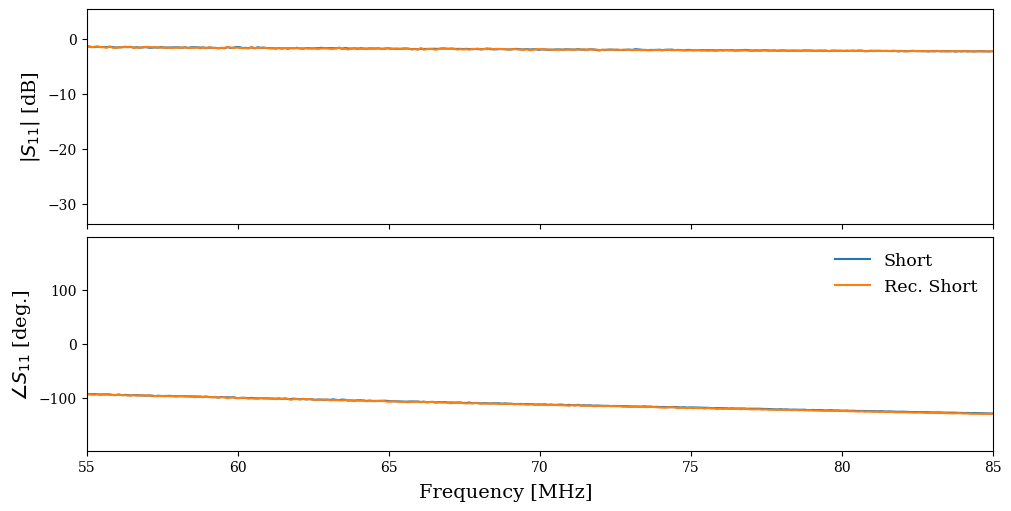

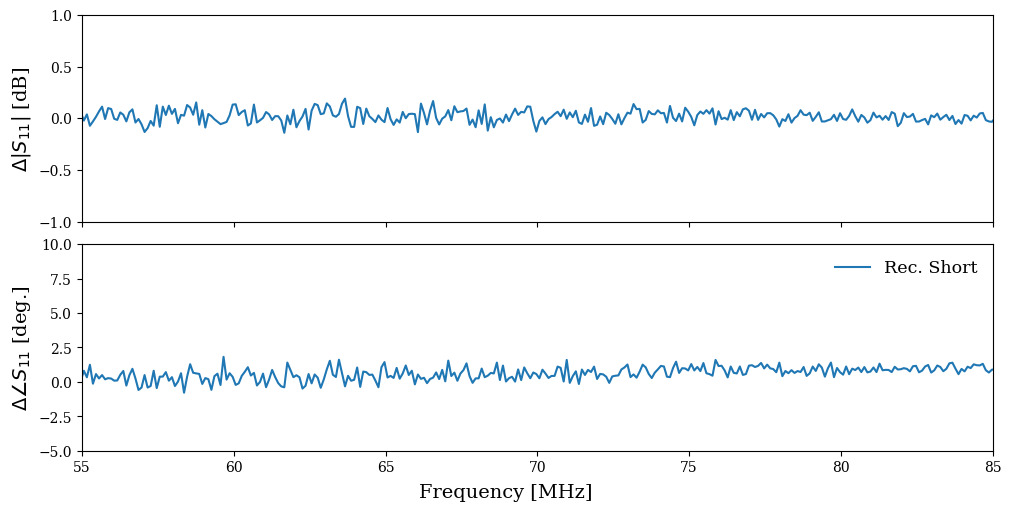

In [27]:
cal_short = Termination('VNA_Measurements_John/cal_s11/cal_short_t1t1e7_0.s2p', label='Short')

sp8t_rf7 = Componant('VNA_Measurements_John/sp8t/sp8t_p7_rf7.s2p', label='SP8T RF7')

short_term = Termination('VNA_Measurements_John/cal_ends/short_0.s2p')

rec_short = LumpedTermination(lumped_componants=sp8t_rf7, termination=short_term, label='Rec. Short')

visualise_s11(termination=[cal_short, rec_short])
visulaise_s11_residuals(prime_termination=cal_short,
terminations=[rec_short], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

### Open Calibrator

In [ ]:
cal_open = Termination('VNA_Measurements_John/cal_s11/cal_open_t1t1e8_0.s2p', label='Short')

sp8t_rf8 = Componant('VNA_Measurements_John/sp8t/sp8t_p8_rf8.s2p', label='SP8T RF8')

open_term = Termination('VNA_Measurements_John/cal_ends/open_0.s2p')

rec_short = LumpedTermination(lumped_componants=sp8t_rf8, termination=open_term, label='Rec. Open')

visualise_s11(termination=[cal_open, rec_short])
visulaise_s11_residuals(prime_termination=cal_open,
terminations=[rec_short], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

In [ ]:
cal_short = Termination('VNA_Measurements_John/cal_s11/cal_short_t1t1e7_0.s2p', label='Short')

sp8t_rf7 = Componant('VNA_Measurements_John/sp8t/sp8t_p7_rf7.s2p', label='SP8T RF7')

short_term = Termination('VNA_Measurements_John/cal_ends/short_0.s2p')

rec_short = LumpedTermination(lumped_componants=sp8t_rf7, termination=short_term, label='Rec. Short')

visualise_s11(termination=[cal_short, rec_short])
visulaise_s11_residuals(prime_termination=cal_short,
terminations=[rec_short], diff_mag_ylim=(-1, 1), diff_pha_ylim=(-5, 10))

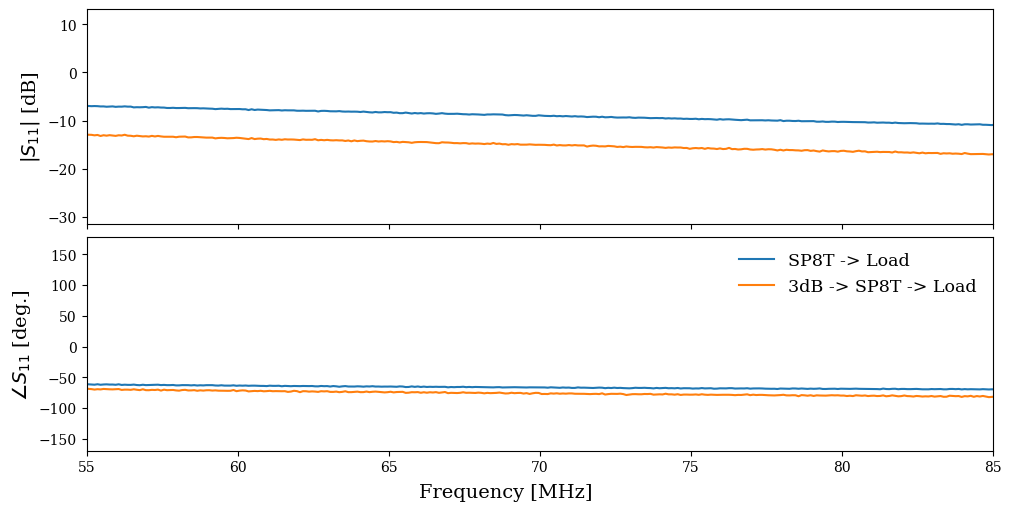

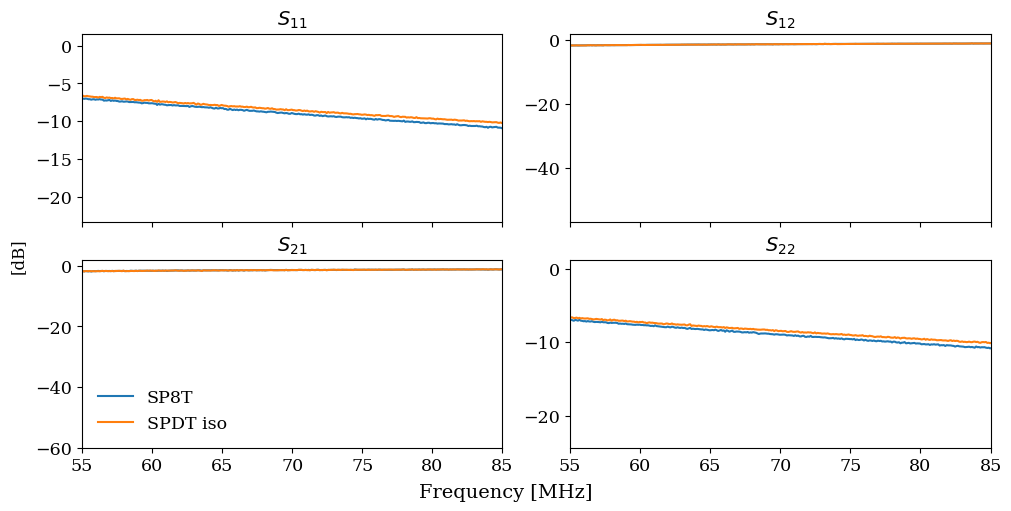

In [ ]:
### Attempt to Reduce Reflections on the Load

threedbPad = Componant('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/3dBatt0.s2p', label='3dB Pad')
sp8t_to_load = Componant('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/sp8t/sp8t_p6_rf6.s2p', label='SP8T')
load_termination = Termination('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/cal_ends/load_0.s2p')

spdt = Componant('/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/spdt1/spdt1_t1_rf1_1.s2p', label='SPDT')

spdt = Componant('VNA_Measurements_John/spdt1/spdt1_t2_rf2_1.s2p', label='SPDT iso')

lumped_comp = LumpedComponants(componants_list=[sp8t_to_load])
lumped_comp_pad = LumpedComponants([threedbPad, sp8t_to_load])
lumped_termination = LumpedTermination(lumped_comp, load_termination, label='SP8T -> Load')
lumped_pad_term = LumpedTermination(lumped_comp_pad, load_termination, label='3dB -> SP8T -> Load')
                        
visualise_s11([lumped_termination, lumped_pad_term])

plot_s_params_mag([sp8t_to_load, spdt])




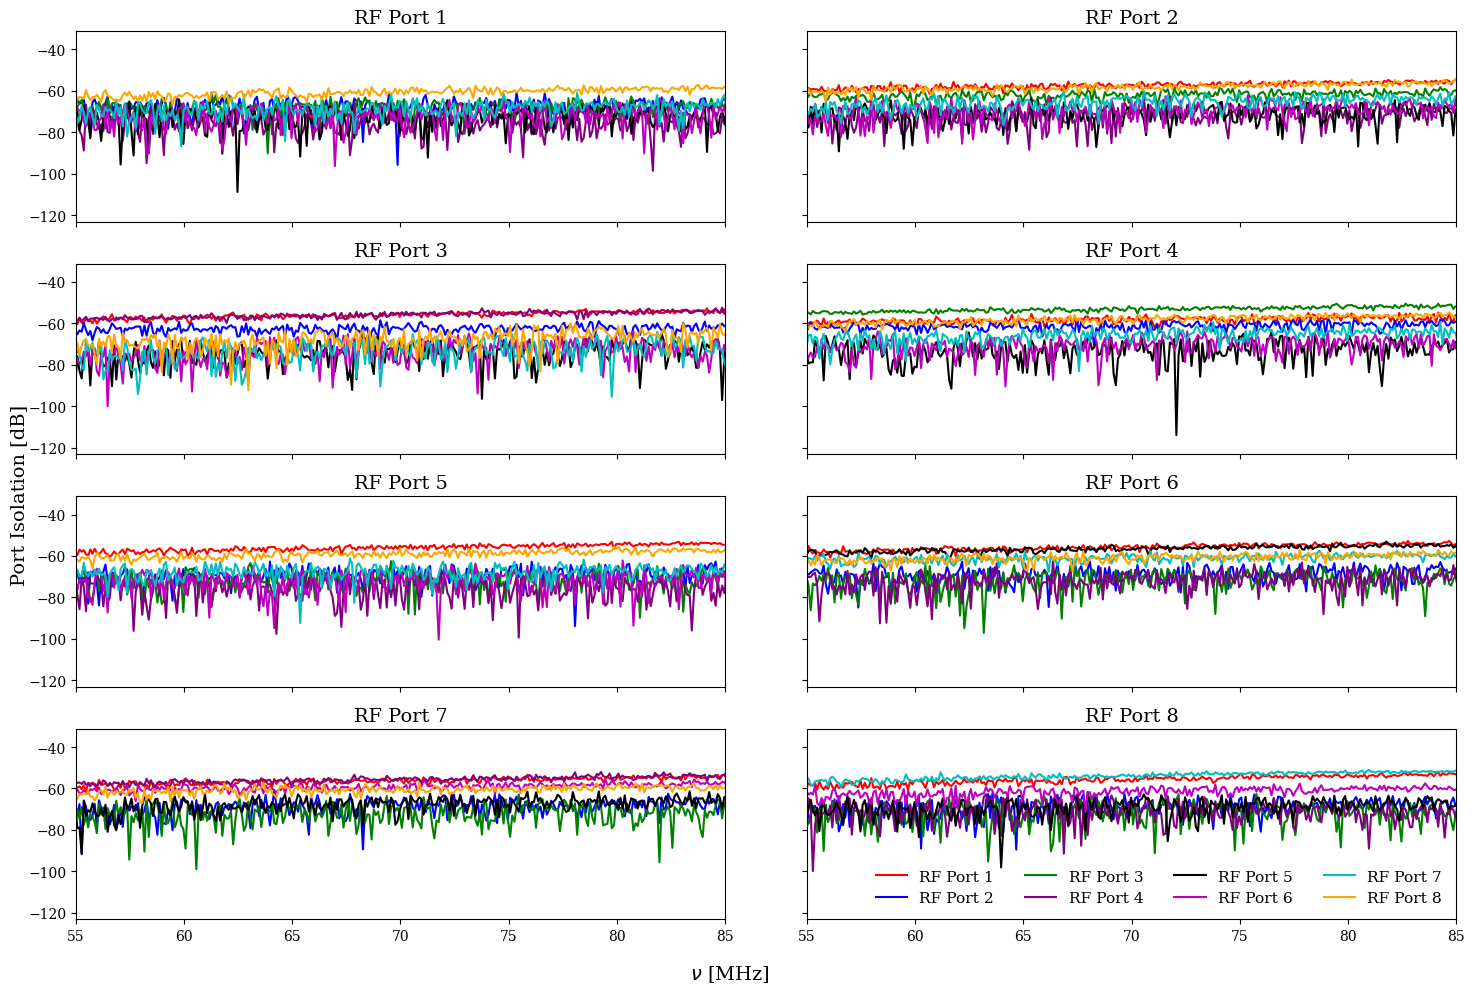

In [14]:
### Plot Isolation
fig, axs = plt.subplots(nrows=4, ncols=2, sharex=True,
                        sharey=True)

port_colors = ['r', 'b', 'g', 'purple', 'k', 'm', 'c', 'orange']

fontsize=14

for i, ax in enumerate(axs.reshape(-1)): 
    ax.set_title(f'RF Port {i+1}', fontsize=fontsize)
    for j in range(1, 9):
        if i+1==j:
            ax.plot([], [], c=port_colors[j-1], label=f'RF Port {j}')
            pass
        else:
            _,s12,_,_, freq = read_s2p(filename=f'VNA_Measurements_John/sp8t/sp8t_p{j}_rf{i+1}.s2p')
            ax.plot(freq / 1e6, 20*np.log10(s12), c=port_colors[j-1], label=f'RF Port {j}')
    ax.set_xlim(55, 85)


handles = []
labels = []
for ax in axs.flat:
    h,l = ax.get_legend_handles_labels()
    handles.extend(h), labels.extend(l)

unique = dict(zip(labels, handles))

fig.supxlabel(r'$\nu$ [MHz]', fontsize=fontsize)
fig.supylabel(r'Port Isolation [dB]', fontsize=fontsize)
axs[-1, -1].legend(unique.values(),
           unique.keys(),
           loc='lower right',
           #bbox_to_anchor=(1.02, 0.1),
           ncols=4,
           fontsize=fontsize*0.8,
           frameon=False)
plt.gcf().set_size_inches((15., 10.))
plt.tight_layout()
plt.savefig('VNA_Measurements_John/Port_Isolation.pdf', dpi=400)
plt.show()
